KNN(k_nearest_neighbors, k-최근접 이웃)

- 가까운 이웃의 다수결로 분류하는 모델
- KNeighborsClassifier, n_neighbors(k)를 사용
- 새 데이터가 들어오면 가장 가까운 k개 이웃을 찾아서 다수결로 

In [56]:
#데이터 분석
import numpy as np
import pandas as pd

#데이터 시각화
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [59]:
iris = load_iris()

In [60]:
X,y = iris.data, iris.target

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y)

In [62]:
#스케일링 없이
knn_raw = KNeighborsClassifier(n_neighbors = 5) # 새로운 데이터가 들어왔을때, 가장 가까운 이웃 데이터 5개를 보고 다수결로 품종을 예측
knn_raw.fit(X_train, y_train)
acc_raw = accuracy_score(y_test, knn_raw.predict(X_test))

In [63]:
acc_raw

1.0

In [64]:
scaled = StandardScaler()
scaled_knn_train = scaled.fit_transform(X_train)
scaled_knn_test = scaled.transform(X_test)
knn_scaled = KNeighborsClassifier(n_neighbors = 5)
knn_scaled.fit(scaled_knn_train, y_train)
scaled_accuracy = accuracy_score(y_test, knn_scaled.predict(scaled_knn_test))
print('스케일링 적용 후 정확도 : ',round(scaled_accuracy,3))

스케일링 적용 후 정확도 :  0.933


# 최적의 k(이웃 수) 찾기

- k가 너무 작으면 예민 = overfitting 발생 가능성이 높아지므로 적절한 k를 찾는것이 중요

In [76]:
# k값을 1 부터 20까지 하나씩 테스트

ks = range(1,21)
find_k = []
# k별로 정확도를 저장할 리스트
acc = []

#가장 좋은 k와 정확도를저장할 변수
best_k = 0
best_acc = 0

#k값을 하나씩 바꿔가면서 knn 모델 학습

for k in ks:
    knn_scaled = KNeighborsClassifier(n_neighbors = k)
    knn_scaled.fit(scaled_knn_train, y_train)
    accuracy = accuracy_score(y_test, knn_scaled.predict(scaled_knn_test))
    acc.append(accuracy)
    if accuracy >= best_acc:
        best_acc = accuracy
        best_k = k
print(f'가장 좋은 k는 {best_k}, 가장 좋은 정확도는 {round(best_acc,3)}')

가장 좋은 k는 20, 가장 좋은 정확도는 0.967


In [77]:
#한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

#경고문 패치
import warnings

warnings.filterwarnings('ignore')

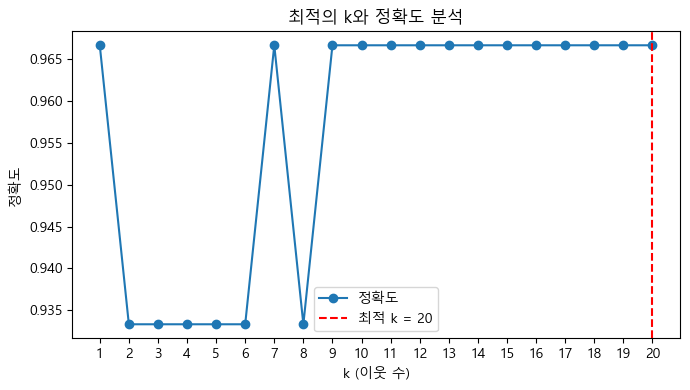

In [80]:
plt.figure(figsize=(7, 4))

plt.plot(ks, acc, marker='o', label='정확도')

plt.axvline(
    best_k,
    color='red',
    linestyle='--',
    label=f'최적 k = {best_k}'
)

plt.xlabel('k (이웃 수)')
plt.ylabel('정확도')
plt.title('최적의 k와 정확도 분석')

plt.xticks(ks)
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
data = [[5.1,3.5,1.4,0.2]]

In [84]:
u_sepal_length = float(input("꽃받침의 길이 : "))
u_sepal_width = float(input("꽃받침의 너비 : "))
u_petal_length = float(input("꽃잎의 길이 : "))
u_petal_width = float(input("꽃잎의 너비 : "))

User_data = pd.DataFrame([
    [u_sepal_length,u_sepal_width,u_petal_length,u_petal_width]],
    columns = iris.feature_names
)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(scaled_knn_train,y_train)
u_pred = knn.predict(User_data)
result = iris.target_names[u_pred[0]]
print(f"예측된 품종은 {result} 입니다")

꽃받침의 길이 :  5.0
꽃받침의 너비 :  3.0
꽃잎의 길이 :  2.0
꽃잎의 너비 :  1.0


예측된 품종은 virginica 입니다
